[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/state-reducers.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239428-lesson-2-state-reducers)

# State Reducers 

## 復習

我們介紹了幾種定義 LangGraph state schema 的不同方式，包括 `TypedDict`、`Pydantic` 或 `Dataclasses`。
 
## 目標

現在，我們要深入探討 reducers，它用來指定 state schema 中特定 key／channel 的 state 更新該如何執行。

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph

## Default overwriting state

讓我們用一個 `TypedDict` 來當作我們的 state schema。

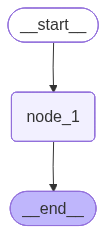

In [1]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

# 建立 graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# 邏輯
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# 加入
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
graph.invoke({"foo" : 1})

---Node 1---


{'foo': 2}

讓我們來看這個 state 更新：`return {"foo": state['foo'] + 1}`。

如同先前討論過的，在預設情況下，LangGraph 並不知道你偏好用什麼方式來更新 state。
 
所以，它就只會在 `node_1` 裡直接覆寫（overwrite）`foo` 的值：

```
return {"foo": state['foo'] + 1}
```
 
如果我們傳入 `{'foo': 1}` 當作 input，那麼從 graph 回傳的 state 就會是 `{'foo': 2}`。

## Branching

讓我們來看一個 nodes 會分支（branch）的情況。

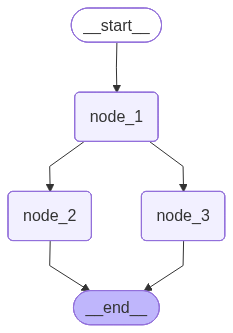

In [3]:
class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

def node_2(state):
    print("---Node 2---")
    return {"foo": state['foo'] + 1}

def node_3(state):
    print("---Node 3---")
    return {"foo": state['foo'] + 1}

# 建立 graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 邏輯
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# 加入
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"foo" : 1})
except InvalidUpdateError as e:
    print(f"InvalidUpdateError occurred: {e}")


---Node 1---
---Node 2---
---Node 3---
InvalidUpdateError occurred: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


我們看到一個問題！

Node 1 分支到 node 2 與 node 3。

Node 2 與 node 3 平行（parallel）執行，也就是說它們在 graph 的同一個 step 中執行。

它們兩個都試圖*在同一個 step 內*覆寫 state。

這對 graph 來說是模稜兩可的！它到底該保留哪一個 state 呢？

## Reducers

[Reducers](https://docs.langchain.com/oss/python/langgraph/graph-api/#reducers) 提供了一種通用的方法來解決這個問題。

它們用來指定更新該如何執行。

我們可以使用 `Annotated` 型別來指定一個 reducer 函式。

舉例來說，在這個例子裡，我們就把每個 node 回傳的值附加（append）上去，而不是覆寫它們。

我們只需要一個能做到這件事的 reducer：`operator.add` 是 Python 內建 operator 模組裡的一個函式。

當 `operator.add` 套用在 lists 上時，它會執行 list 的串接（concatenation）。

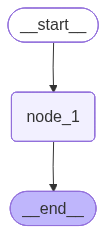

In [5]:
from operator import add
from typing import Annotated

class State(TypedDict):
    foo: Annotated[list[int], add]

def node_1(state):
    print("---Node 1---")
    return {"foo": [state['foo'][0] + 1]}

# 建立 graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# 邏輯
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# 加入
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
graph.invoke({"foo" : [1]})

---Node 1---


{'foo': [1, 2]}

現在，我們的 state key `foo` 是一個 list。

這個 `operator.add` reducer 函式會把每個 node 的更新附加（append）到這個 list 上。

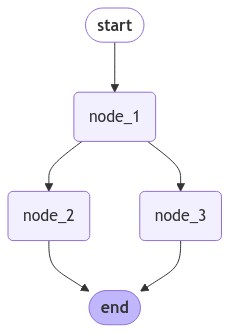

In [7]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [state['foo'][-1] + 1]}

def node_2(state):
    print("---Node 2---")
    return {"foo": [state['foo'][-1] + 1]}

def node_3(state):
    print("---Node 3---")
    return {"foo": [state['foo'][-1] + 1]}

# 建立 graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 邏輯
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# 加入
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

我們可以看到 node 2 與 node 3 裡的更新是同時（concurrently）執行的，因為它們處於同一個 step。

In [8]:
graph.invoke({"foo" : [1]})

---Node 1---
---Node 2---
---Node 3---


{'foo': [1, 2, 3, 3]}

現在，讓我們看看如果把 `None` 傳給 `foo` 會發生什麼事。

我們會看到一個錯誤，因為我們的 reducer `operator.add` 試圖把當作 input 傳進來的 `NoneType` 與 `node_1` 裡的 list 做串接。

In [7]:
try:
    graph.invoke({"foo" : None})
except TypeError as e:
    print(f"TypeError occurred: {e}")

TypeError occurred: can only concatenate list (not "NoneType") to list


## Custom Reducers

為了處理像這樣的情況，[我們也可以自己定義 custom reducers](https://docs.langchain.com/oss/python/langgraph/use-graph-api#process-state-updates-with-reducers)。

舉例來說，讓我們定義一段 custom reducer 邏輯，用來合併 lists，並處理其中一個或兩個 input 都可能是 `None` 的情況。

In [8]:
def reduce_list(left: list | None, right: list | None) -> list:
    """安全地合併兩個 lists，並處理其中一個或兩個 input 都可能是 None 的情況。

    Args:
        left (list | None): 要合併的第一個 list，或為 None。
        right (list | None): 要合併的第二個 list，或為 None。

    Returns:
        list: 一個新的 list，包含兩個 input list 的所有元素。
               若某個 input 為 None，會被視為空 list。
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class DefaultState(TypedDict):
    foo: Annotated[list[int], add]

class CustomReducerState(TypedDict):
    foo: Annotated[list[int], reduce_list]

在 `node_1` 裡，我們附加（append）值 2。

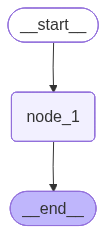

TypeError occurred: can only concatenate list (not "NoneType") to list


In [9]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [2]}

# 建立 graph
builder = StateGraph(DefaultState)
builder.add_node("node_1", node_1)

# 邏輯
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# 加入
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    print(graph.invoke({"foo" : None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

現在，換成我們的 custom reducer 試試看。我們可以看到並沒有拋出任何錯誤。

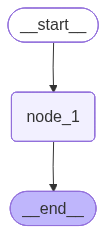

---Node 1---
{'foo': [2]}


In [10]:
# 建立 graph
builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)

# 邏輯
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# 加入
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    print(graph.invoke({"foo" : None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

## Messages

在 module 1，我們示範了如何使用內建的 reducer `add_messages` 來處理 state 裡的 messages。

我們也示範了 [`MessagesState` 是一個很方便的捷徑，適合用在你想處理 messages 的時候](https://docs.langchain.com/oss/python/langgraph/use-graph-api#messagesstate)。

* `MessagesState` 內建了一個 `messages` key 
* 它也為這個 key 內建了一個 `add_messages` reducer

這兩種寫法是等價的。

為了簡潔，我們會透過 `from langgraph.graph import MessagesState` 來使用 `MessagesState` 類別。


In [29]:
from typing import Annotated
from langgraph.graph import MessagesState
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# 定義一個 custom TypedDict，內含一個帶有 add_messages reducer 的 messages list
class CustomMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    added_key_1: str
    added_key_2: str
    # 等等

# 使用 MessagesState，它內含帶有 add_messages reducer 的 messages key
class ExtendedMessagesState(MessagesState):
    # 在預先內建的 messages 之外，加入任何你需要的 key 
    added_key_1: str
    added_key_2: str
    # 等等

讓我們再多談一點 `add_messages` reducer 的用法。

In [13]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage

# 初始 state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# 要加入的新 message
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# 測試
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', name='Model', id='f470d868-cf1b-45b2-ae16-48154cd55c12'),
 HumanMessage(content="I'm looking for information on marine biology.", name='Lance', id='a07a88c5-cb2a-4cbd-9485-5edb9d658366'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', name='Model', id='7938e615-86c2-4cbb-944b-c9b2342dee68')]

所以我們可以看到，`add_messages` 讓我們能夠把 messages 附加（append）到 state 裡的 `messages` key 上。

### Re-writing

讓我們示範一些在使用 `add_messages` reducer 時很實用的小技巧。

如果我們傳入一個 message，它的 ID 與 `messages` list 裡某個既有的 message 相同，那麼那個 message 就會被覆寫！

In [14]:
# 初始 state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model", id="1"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance", id="2")
                   ]

# 要加入的新 message
new_message = HumanMessage(content="I'm looking for information on whales, specifically", name="Lance", id="2")

# 測試
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', name='Model', id='1'),
 HumanMessage(content="I'm looking for information on whales, specifically", name='Lance', id='2')]

### Removal

我們可以使用 [RemoveMessage](https://docs.langchain.com/oss/python/langgraph/add-memory#delete-messages) 來移除 messages。

In [15]:
from langchain_core.messages import RemoveMessage

# Message list
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# 挑出要刪除的 messages
delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]
print(delete_messages)

[RemoveMessage(content='', id='1'), RemoveMessage(content='', id='2')]


/var/folders/l9/bpjxdmfx7lvd1fbdjn38y5dh0000gn/T/ipykernel_17703/3097054180.py:10: LangChainBetaWarning: The class `RemoveMessage` is in beta. It is actively being worked on, so the API may change.
  delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]


In [16]:
add_messages(messages , delete_messages)

[AIMessage(content='So you said you were researching ocean mammals?', name='Bot', id='3'),
 HumanMessage(content='Yes, I know about whales. But what others should I learn about?', name='Lance', id='4')]

我們可以看到，如同 `delete_messages` 裡所標示的，message ID 1 與 2 被 reducer 移除了。

稍後我們會看到這個技巧實際運用在哪裡。